# Robotics control and GMM-guided motion planning

This notebook follows **theory → executable code → measured or preserved result → interpretation**. The primary portfolio component is the corrected Python kinematic planner. MATLAB is retained as an independent legacy dynamics/PID study.

Evidence labels used here:

- **Corrected reproducible result:** generated by the tracked Python source and seeded benchmark.
- **Historical result:** preserved from the original project; exact source alignment is unresolved.
- **Documented limitation:** information that cannot be recovered without inventing physical data.

## 1. Project architecture

The repository contains two computationally independent paths:

1. **Python:** internally consistent 3R+1P kinematics, spherical obstacles, complete-link clearance, scenario-specific GMM residual sampling, sampled candidate ranking, and first-action execution.
2. **MATLAB:** a corrected implementation of a historical simplified numerical dynamics and PID exercise.

Python trajectories are not executed through the MATLAB plant. No common DH model, state channel, torque interface, or validated parameter map exists.

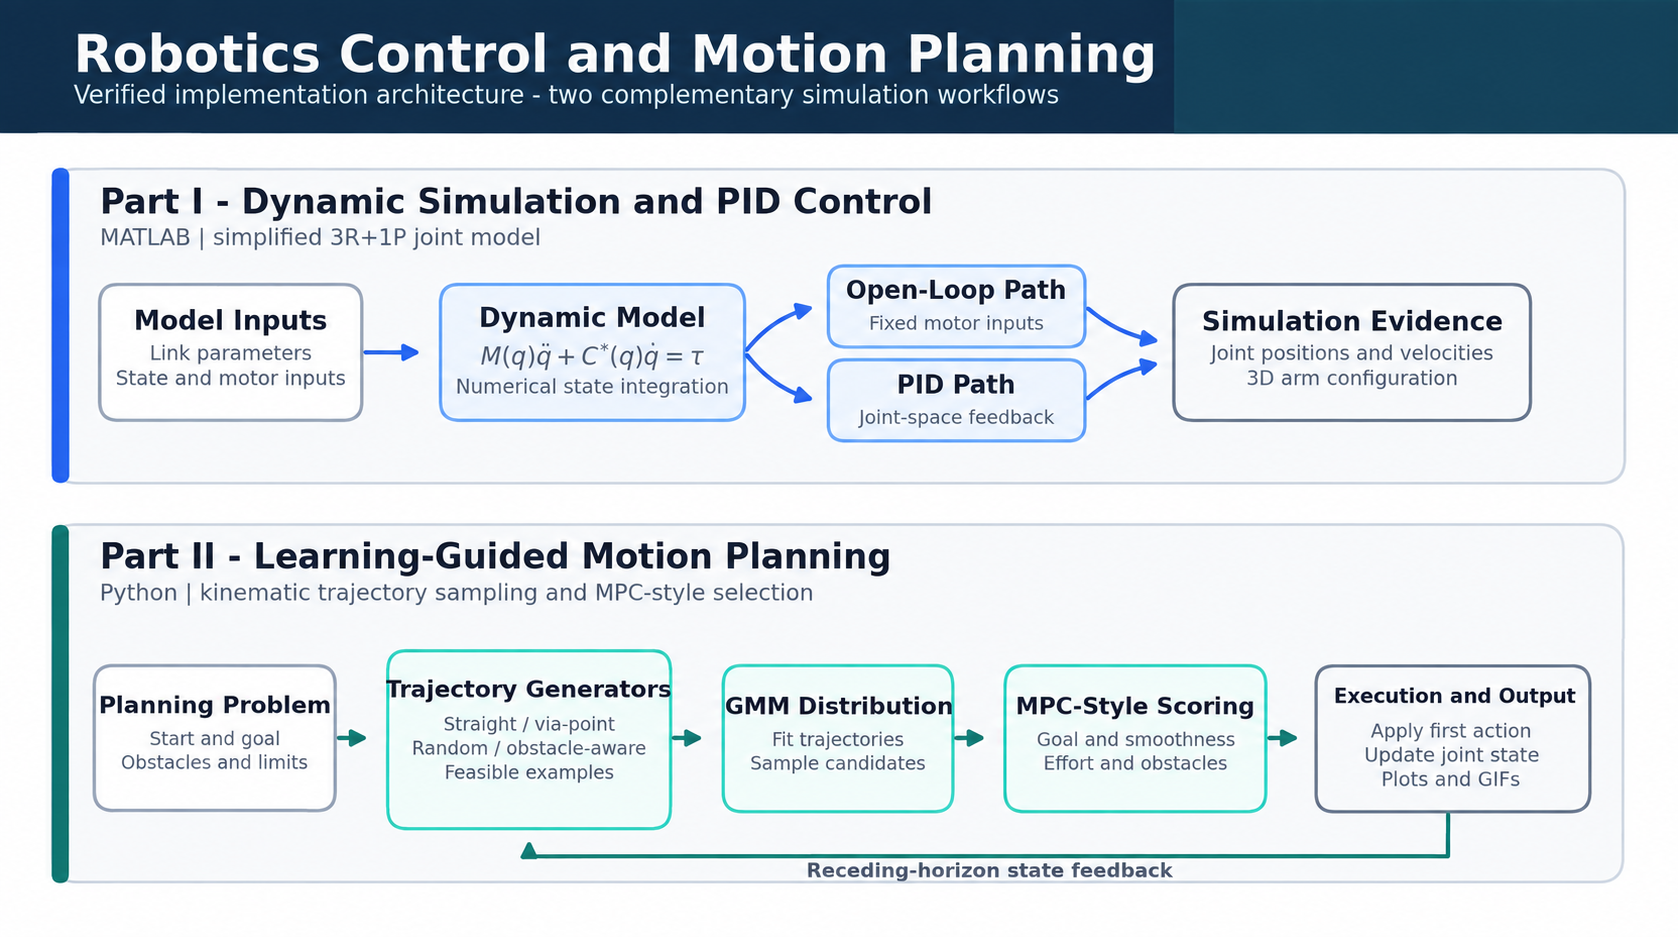

The image is a conceptual project map. Its MATLAB block must be interpreted with the legacy-model limitations in Section 6.

### 1.1 Preserved mechanism schematic

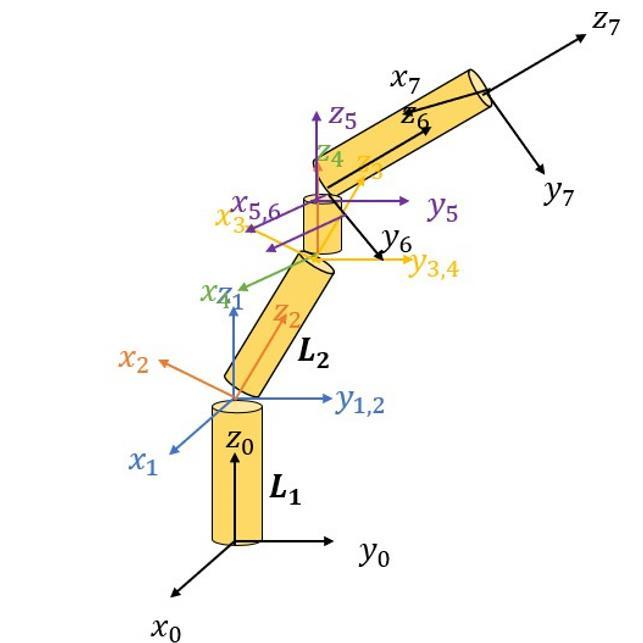

This project-supplied schematic communicates the intended three-revolute-plus-one-prismatic mechanism and the role of the generalized coordinates. It is retained as a **historical result** and conceptual aid. The MATLAB and corrected Python implementations use different frame conventions, so the drawing is not an exact frame-by-frame specification of both programs; the equations in Section 2 define the geometry used by the executable Python planner.

## 2. Corrected Python forward kinematics

### 2.1 Theory

Let $q=[\theta_1,\theta_2,\theta_3,d_4]^T$. The corrected Python planner uses yaw $\theta_1$, two radial-plane pitch coordinates, and a prismatic extension. With

$$r(\theta_1)=[\cos\theta_1,\sin\theta_1,0]^T,$$

$$p_1=L_1e_z,\qquad p_2=p_1+L_2r(\theta_1),$$

$$p_3=p_2+L_3[\cos\theta_2\,r(\theta_1)+\sin\theta_2\,e_z],$$

$$p_4=p_3+L_4[\cos(\theta_2+\theta_3)r(\theta_1)+\sin(\theta_2+\theta_3)e_z],$$

and $p_{ee}=p_4+d_4\hat d_4$. Thus each fixed vector has its declared length. The old unused `L5` value was removed. This is an independent planner geometry, not a claimed recovery of the MATLAB frames.

In [ ]:
from pathlib import Path
import json, sys
import numpy as np

repo_root = Path.cwd().resolve()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src' / 'python'))

from part2_control import HedgeTrimmingRobot, Environment, MotionPlanningSimulation

robot = HedgeTrimmingRobot()
configurations = [
    np.array([0.0, 0.0, 0.0, 0.01]),
    np.array([0.4, 0.7, -0.3, 0.02]),
    np.array([1.0, 1.0, 0.5, 0.03]),
]
for q in configurations:
    positions = np.asarray(robot.forward_kinematics(q))
    print(np.linalg.norm(np.diff(positions, axis=0), axis=1))

### 2.2 Result and interpretation

The executable cell should print `[0.1125, 0.2, 0.05, 0.2, d4]` for every configuration. The automated suite repeats this invariant at zero and nonzero angles and separately verifies that prismatic motion does not move the preceding joints. This removes the former angle-dependent rigid-link lengths.

## 3. Complete-link collision checking

### 3.1 Theory

For segment $[a,b]$, obstacle center $c$, obstacle radius $r$, and link safety radius $r_s=0.02$ m,

$$\alpha^*=\operatorname{clip}\left(\frac{(c-a)^T(b-a)}{\lVert b-a\rVert^2},0,1\right),\qquad p^*=a+\alpha^*(b-a),$$

$$\delta=\lVert c-p^*\rVert-(r+r_s).$$

The signed post-radius clearance is the link-centerline-to-obstacle-center distance minus obstacle radius minus the 0.02 m link radius. Edges near obstacles are adaptively bisected down to at most 0.25 degrees angular and 0.25 mm prismatic intervals. Feasibility additionally requires $\delta>0.0005$ m. The same swept evaluator drives hard feasibility, the soft cost, selected-edge verification, fallback safety, execution safety, and reporting. This is adaptive discretized checking, not analytic continuous collision detection.

In [ ]:
environment = Environment()
for scenario in MotionPlanningSimulation.historical_scenarios():
    start_clearance = environment.configuration_clearance(robot, scenario.q_start)
    goal_clearance = environment.configuration_clearance(robot, scenario.q_goal)
    direct_clearance = environment.swept_path_min_clearance(
        robot, scenario.q_start, scenario.q_goal
    )
    print(scenario.name, start_clearance, goal_clearance, direct_clearance)

### 3.2 Result and interpretation

Under corrected geometry and segment checking, the historical Point-to-Point goal has approximately `-0.0217 m` signed clearance and the historical Obstacle Avoidance goal approximately `-0.0880 m`. They are invalid benchmark endpoints. The repository preserves these definitions for provenance and uses separately named synthetic benchmark queries whose endpoints are positive-clearance configurations. No historical goal was silently moved.

## 4. Scenario-specific GMM-guided sampling

### 4.1 Theory

The planner attempts straight, via-point, randomized, and safe-exploration rollouts. Feasible examples are represented as residuals around the step-limited straight baseline $b$:

$$\rho=\operatorname{vec}(\xi_{1:N-1}-b_{1:N-1}).$$

A full-covariance mixture is fitted,

$$p(\rho)=\sum_{k=1}^{K}\pi_k\mathcal N(\rho\mid\mu_k,\Sigma_k),\qquad K\leq3.$$

The current configuration is enforced by omitting the first residual from the learned vector and prepending the exact start at reconstruction. The terminal state is not overwritten: terminal error remains an active objective. Separate local training and online `numpy.random.Generator` streams are derived reproducibly from every run seed.

This is **scenario-specific trajectory-distribution fitting**. The model receives no map encoding and makes no generalization claim.

### 4.2 Sampled receding-horizon objective

For each feasible candidate,

$$J=\sum_t\Delta t\left[w_te_{q,t}^TQ_qe_{q,t}+w_tq_p\lVert p_{ee}(q_t)-p_{ee}(q_g)\rVert^2+\dot q_t^TQ_v\dot q_t+q_c\max(0,d_{soft}-\delta_t)^2\right]+e_{q,N-1}^TQ_Te_{q,N-1}.$$

The matrices are numerical ranking weights rather than physical energies. One `dt=0.05 s` is used for candidate velocity, first-action execution, state history, and reported simulated duration. `mean_selected_horizon_cost` is only the mean online candidate-ranking value. A separate cumulative `realized_trajectory_cost` evaluates every executed state and swept edge, including fallback and stationary steps, with unphased configuration, task, velocity, clearance, and terminal terms. The method does not claim continuous optimization or global optimality.

### 4.3 Preserved planning visualizations

The following figures were supplied with the original project and are retained as **historical results**. They were not regenerated by the corrected benchmark in Section 5 and are not used to compute its metrics.

#### Point-to-point motion

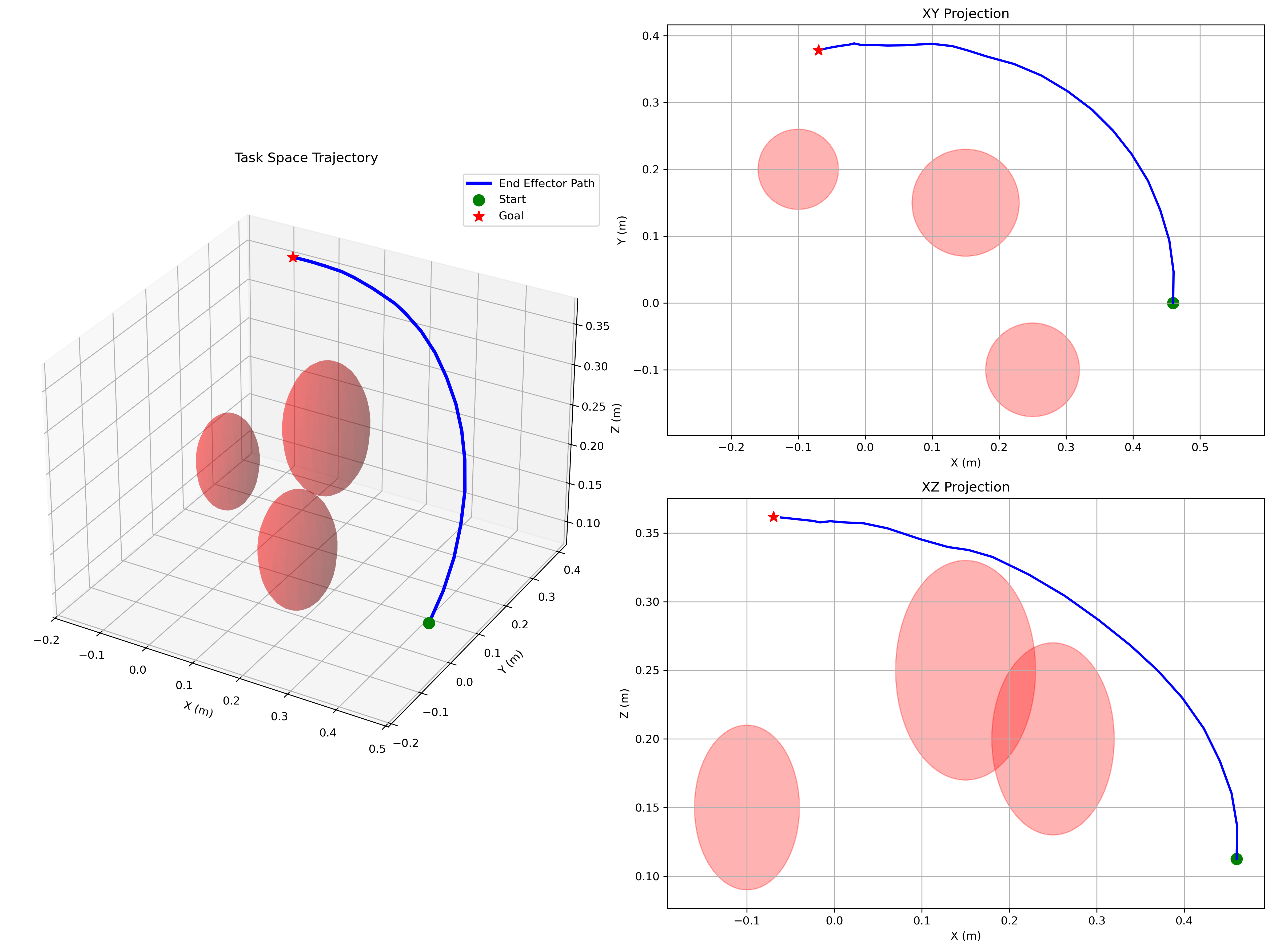

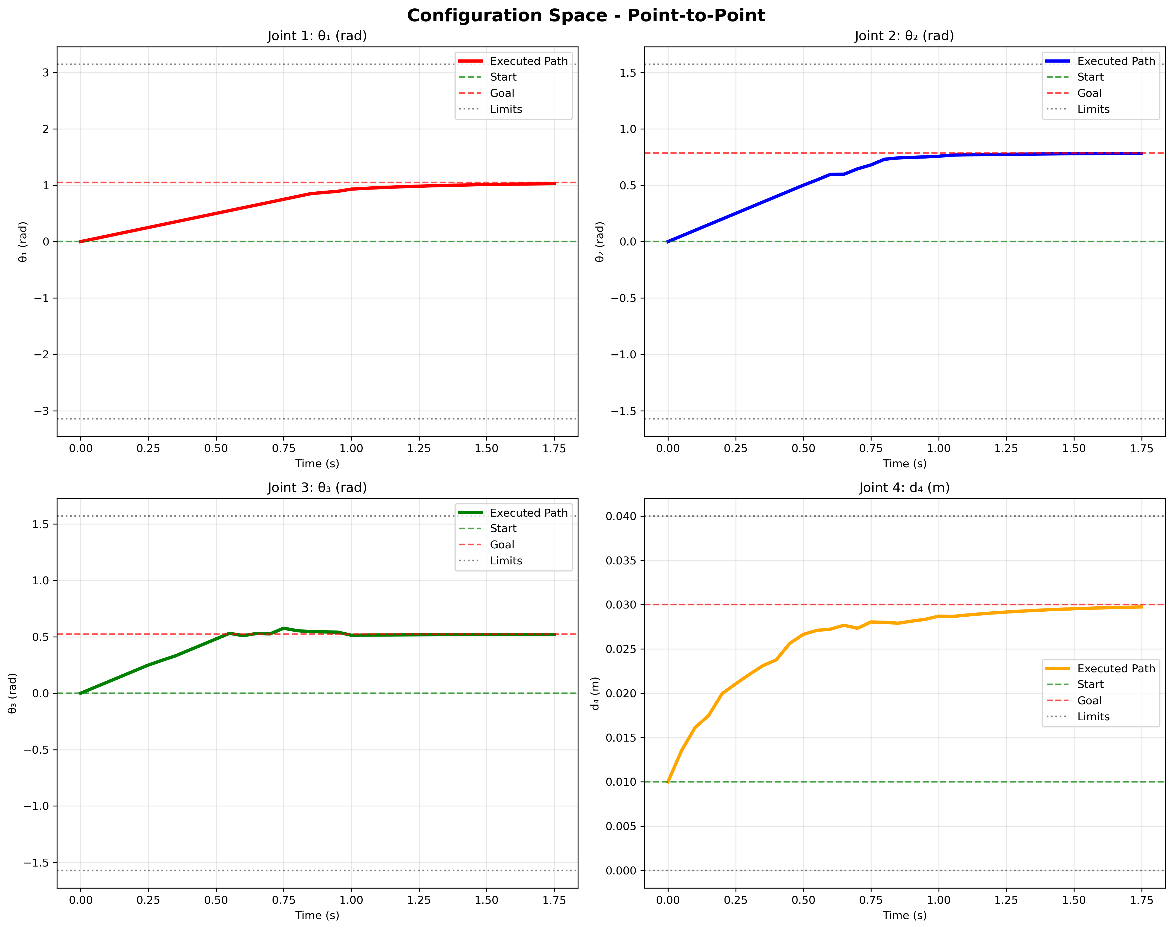

The task-space curve shows the end-effector moving toward the displayed target, while the configuration-space traces show the joint coordinates approaching their displayed references. This is qualitatively consistent with repeated sampled candidate selection and first-action execution.

#### Complex maneuvering

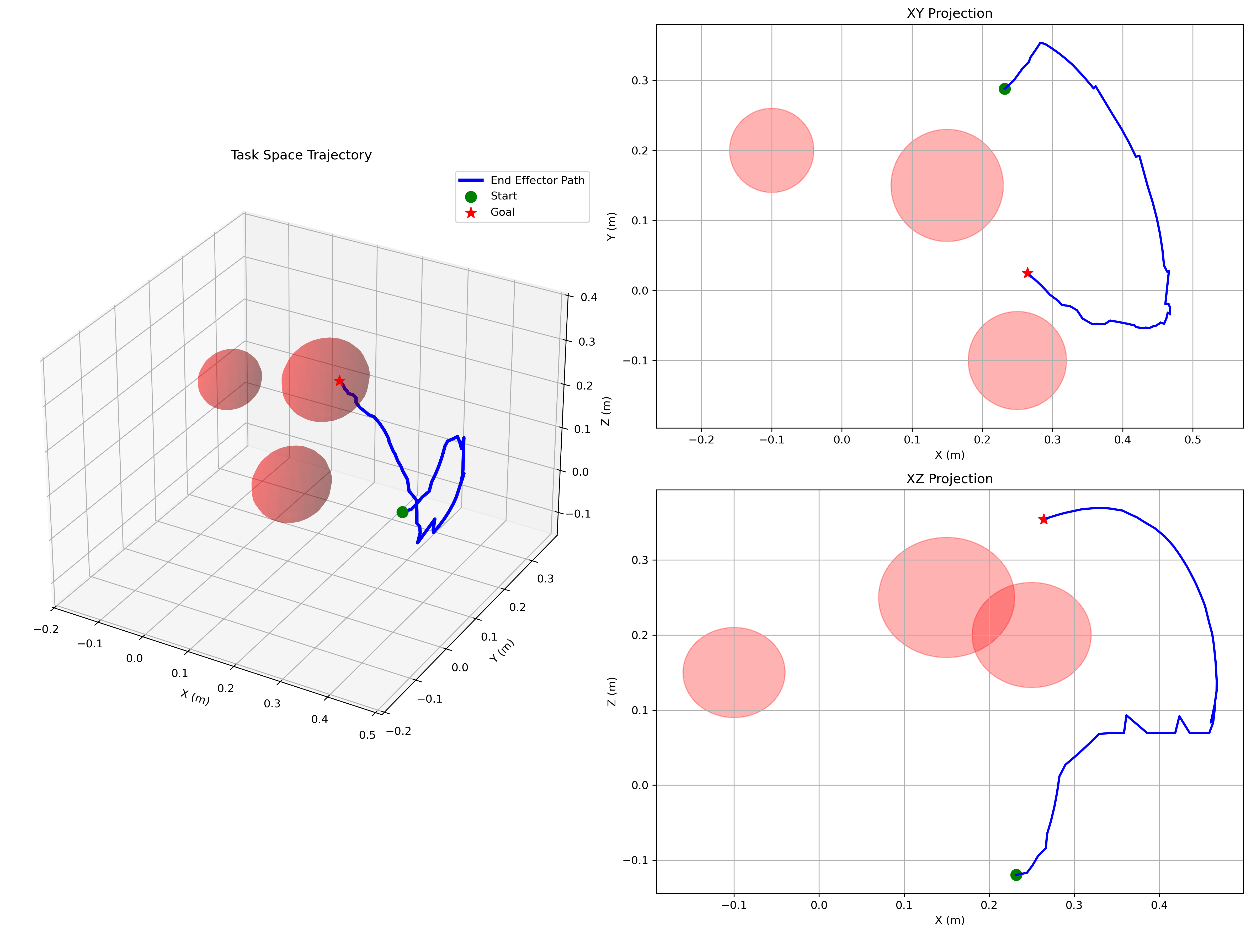

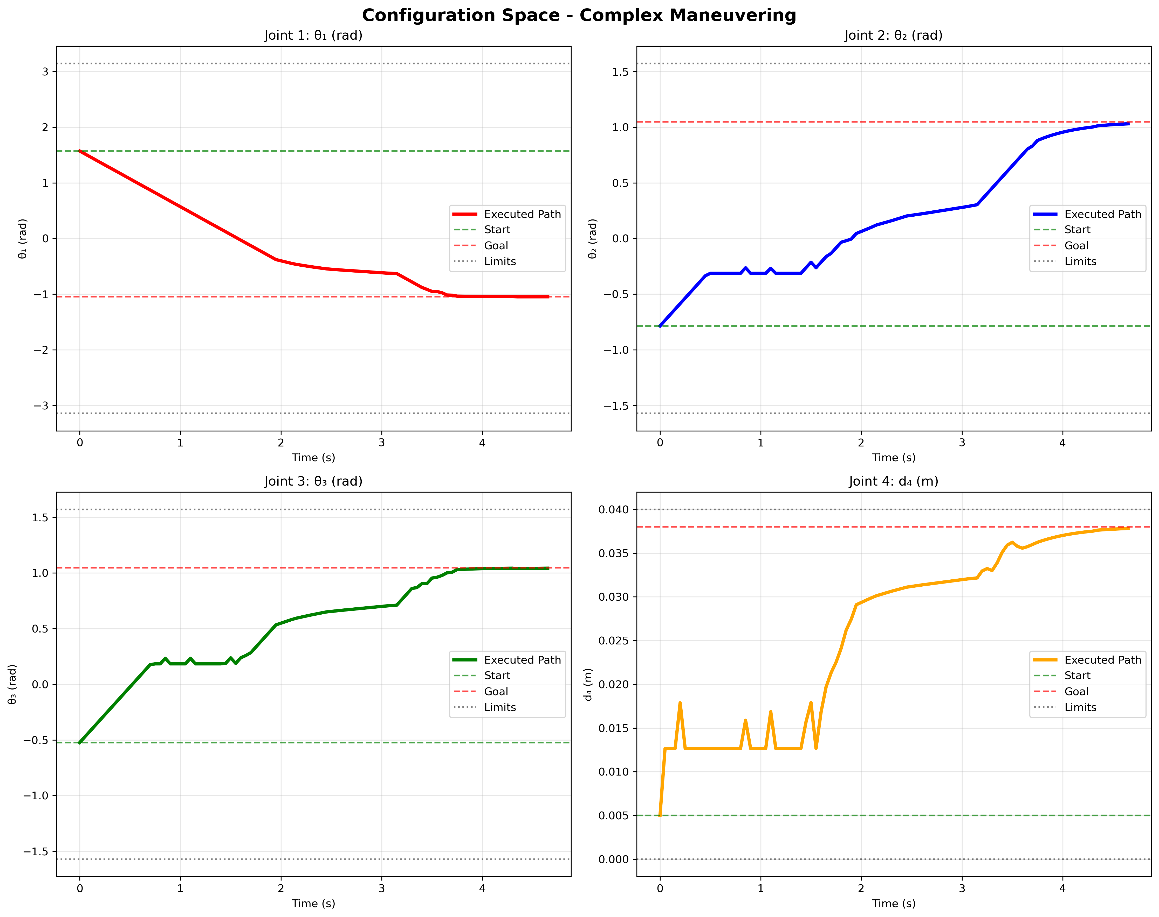

The complex trajectory contains non-monotonic corrections, particularly in the prismatic coordinate, which is qualitatively compatible with repeated replanning around obstacle penalties. The figures support a visual account of the historical run only: they do not establish collision-free swept-link motion, success rate, computation time, or superiority over another planner. The exact run configuration is unresolved because the supplied screenshots and the tracked historical scenario definitions do not align completely.

In [ ]:
benchmark_path = repo_root / 'results' / 'corrected' / 'benchmark' / 'benchmark-results.json'
benchmark = json.loads(benchmark_path.read_text(encoding='utf-8'))
for row in benchmark['overall']:
    print({
        'mode': row['mode'],
        'runs': row['runs'],
        'safe_success_rate': row['safe_success_rate'],
        'safe_success_ci95': [row['safe_success_rate_ci95_lower'], row['safe_success_rate_ci95_upper']],
        'collision_failure_rate': row['collision_failure_rate'],
        'mean_end_effector_error_m': row['end_effector_error_m_mean'],
        'worst_case_clearance_m': row['worst_case_minimum_clearance_m'],
        'planning_time_p95_s': row['planning_step_time_p95_s'],
        'deadline_miss_fraction': row['planning_step_deadline_miss_fraction'],
    })

## 5. Corrected benchmark result

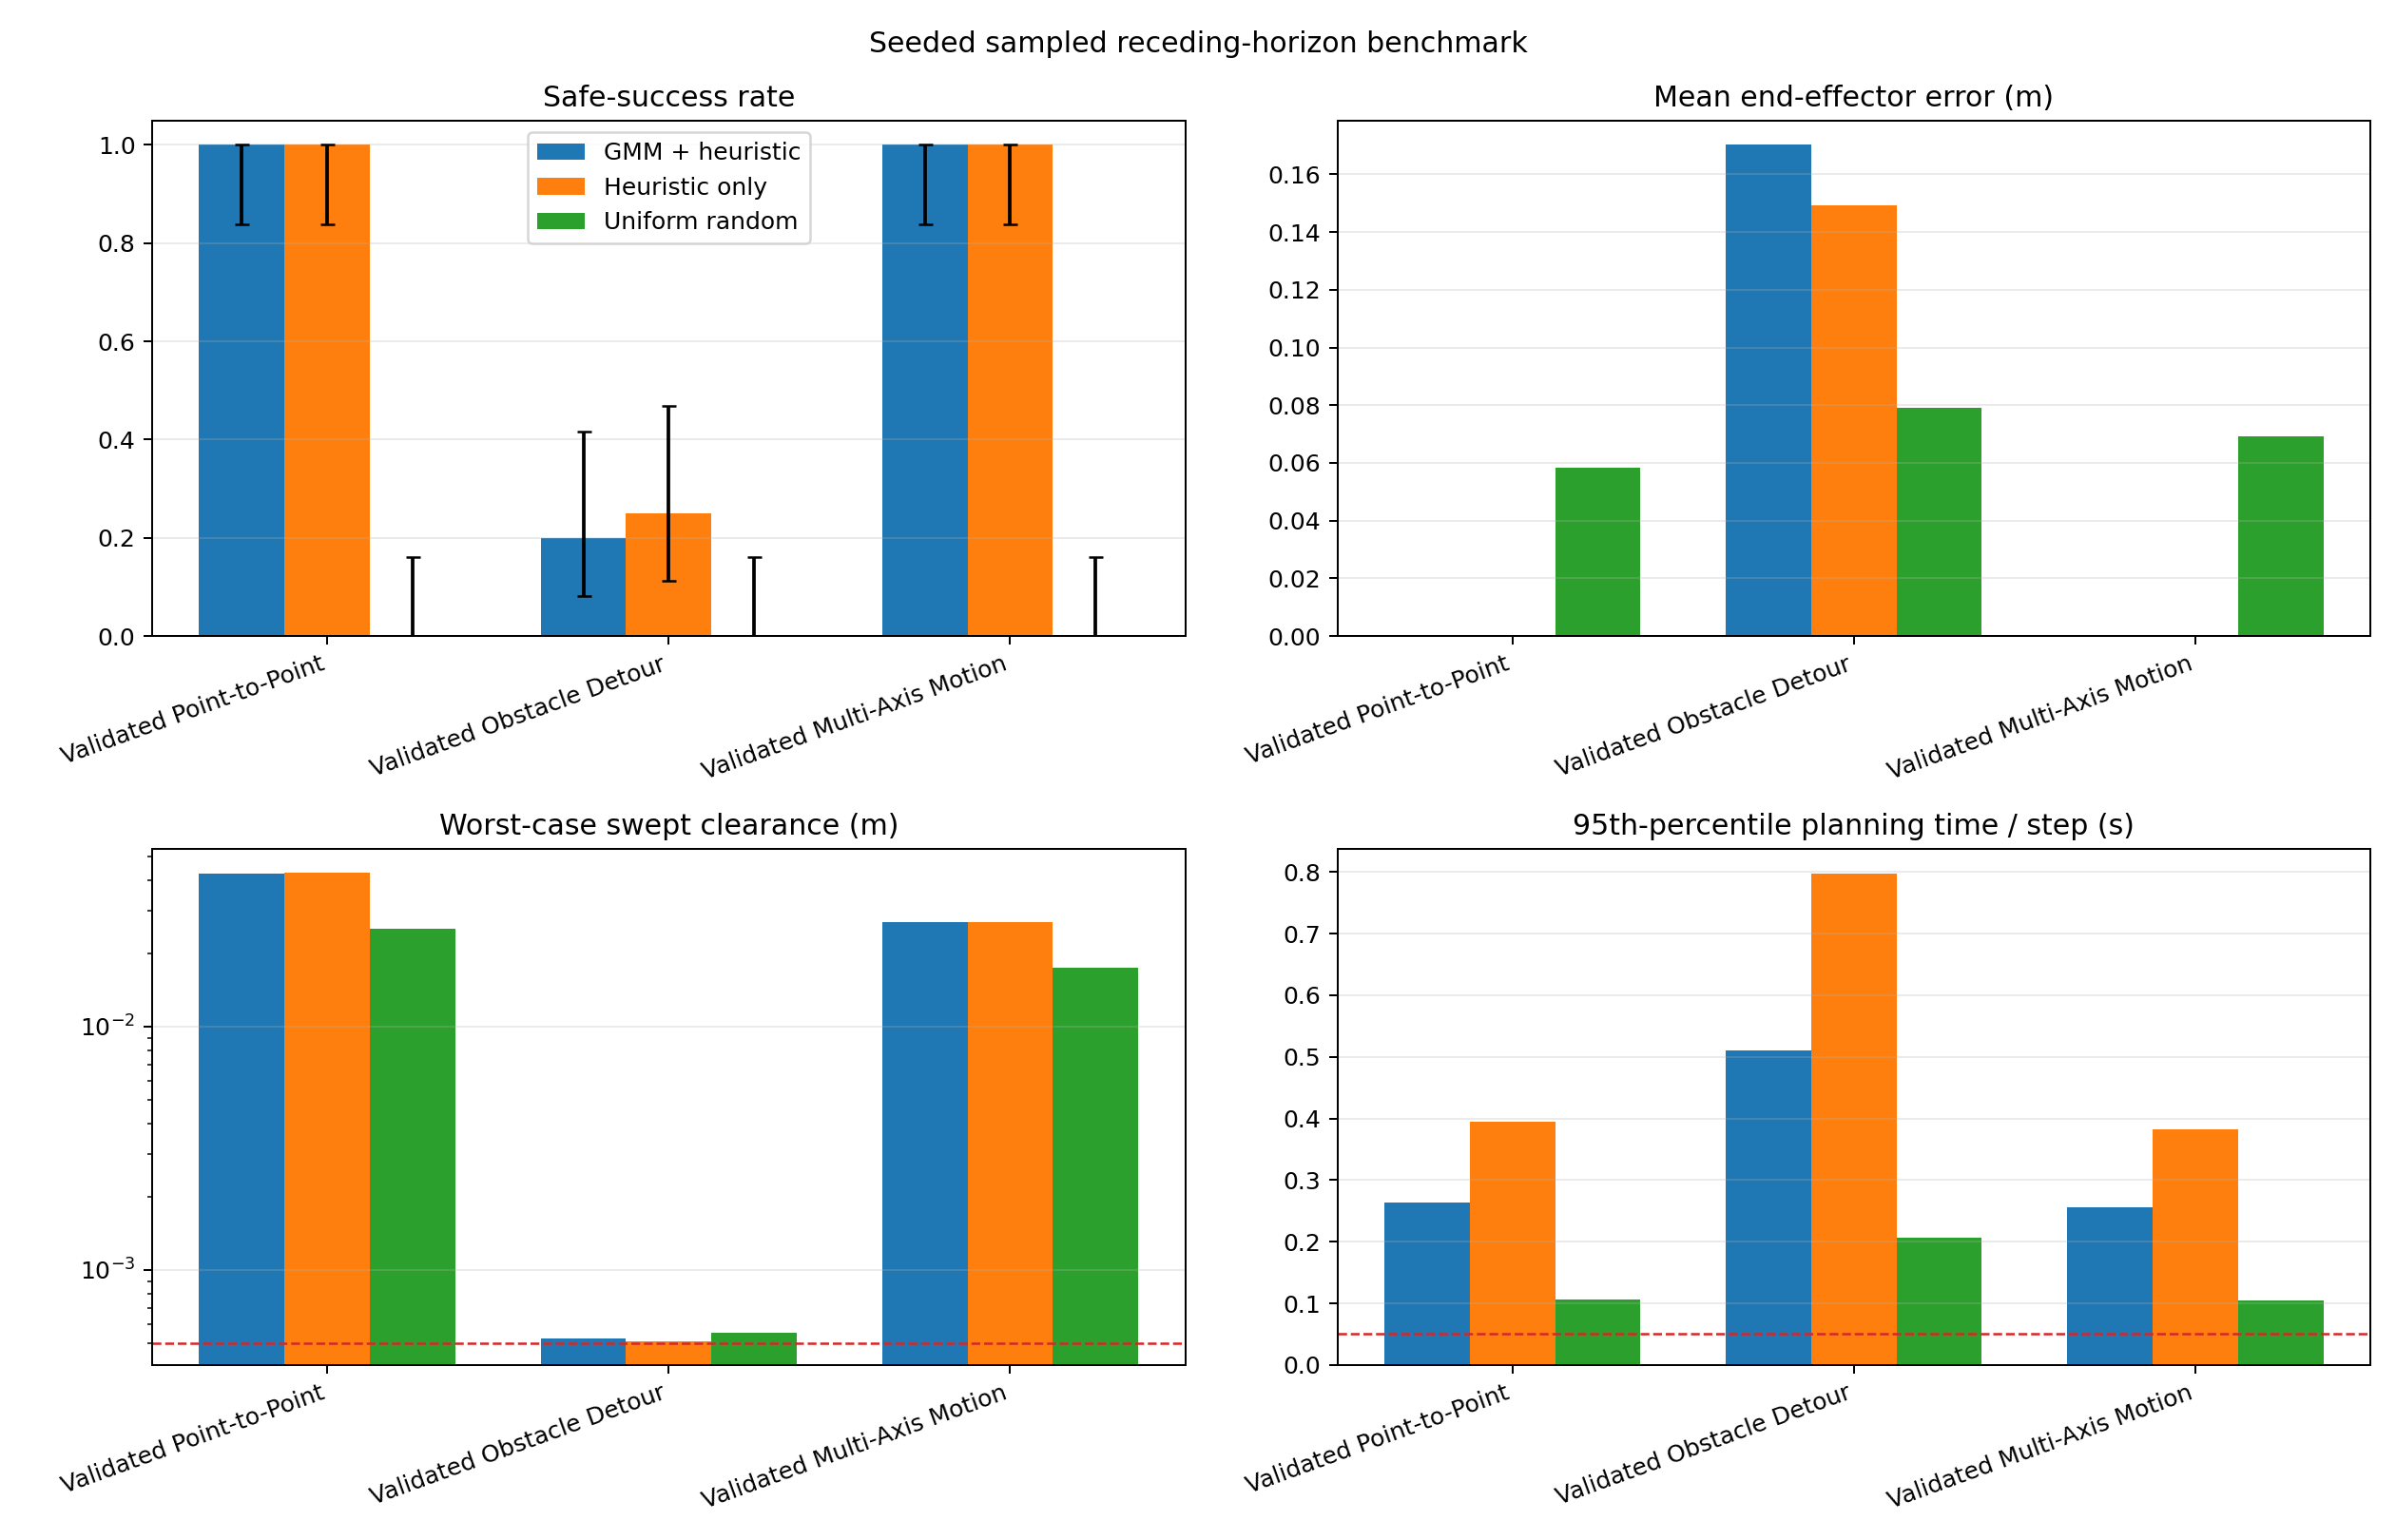

| Mode | Safe successes | Wilson 95% CI | Collision failures | Mean EE error | Worst clearance | Planning p95 | Deadline misses |
|---|---:|---:|---:|---:|---:|---:|---:|
| GMM + heuristic | 44/60 | 61.0–82.9% | 0/60 | 0.0568 m | 0.000525 m | 0.482 s | 96.3% |
| Heuristic only | 45/60 | 62.8–84.2% | 0/60 | 0.0498 m | 0.000508 m | 0.742 s | 99.0% |
| Uniform random | 0/60 | 0.0–6.0% | 0/60 | 0.0689 m | 0.000551 m | 0.169 s | 87.5% |

Configuration: seeds 0 through 19; three synthetic endpoint-checked queries; 12 candidates per step; 48 attempted GMM training trajectories; 10-state horizon; 5 s limit. Safe success means completed 0.5 s goal dwell without a collision failure.

### 5.1 Interpretation

This is a candidate-count-matched benchmark, not an equal-compute benchmark. Every mode shares scenarios, horizon, time step, online candidate count, cost, checker, execution, and stopping criteria, but candidate-generation cost differs. Heuristic-only completed 45 safe runs and GMM + heuristic 44; the data do not show GMM superiority. Per-scenario obstacle-detour safe success was 5/20 (Wilson CI 11.2–46.9%) and 4/20 (CI 8.1–41.6%) respectively; uniform completed no dwell-qualified safe run (CI 0–16.1%).

No executed edge violated the configured adaptive checker, but worst post-radius clearances were only 0.000508–0.000551 m against a 0.0005 m acceptance tolerance. This does not prove exact or physical collision avoidance. Mean online step times were 0.224 s (GMM), 0.361 s (heuristic), and 0.093 s (uniform), all above the 0.05 s control period; deadline-miss fractions were 96.3%, 99.0%, and 87.5%. GMM fitting is excluded from online planning time and reported separately; mean scenario-specific fitting time was 1.056 s.

## 6. MATLAB legacy dynamics and PID

### 6.1 Intended numerical structure

The historical study uses a constant diagonal matrix and a configuration-dependent gravity expression:

$$M_{legacy}\ddot q+g_{legacy}(q)=u.$$

The repair makes vectors dimensionally explicit, refreshes state and velocity, uses the old velocity in the constant-acceleration position update, and applies the documented sampled PID bookkeeping:

$$I_k=I_{k-1}+e_k\Delta t,\qquad D_k=\frac{e_k-e_{k-1}}{\Delta t},$$

$$u_k=K_pe_k+K_iI_k+K_dD_k.$$

The fourth coordinate now uses acceleration component four. The overshoot-triggered break was removed, preventing untouched preallocated zeros from being presented as a physical return to zero.

### 6.2 Preserved open-loop results

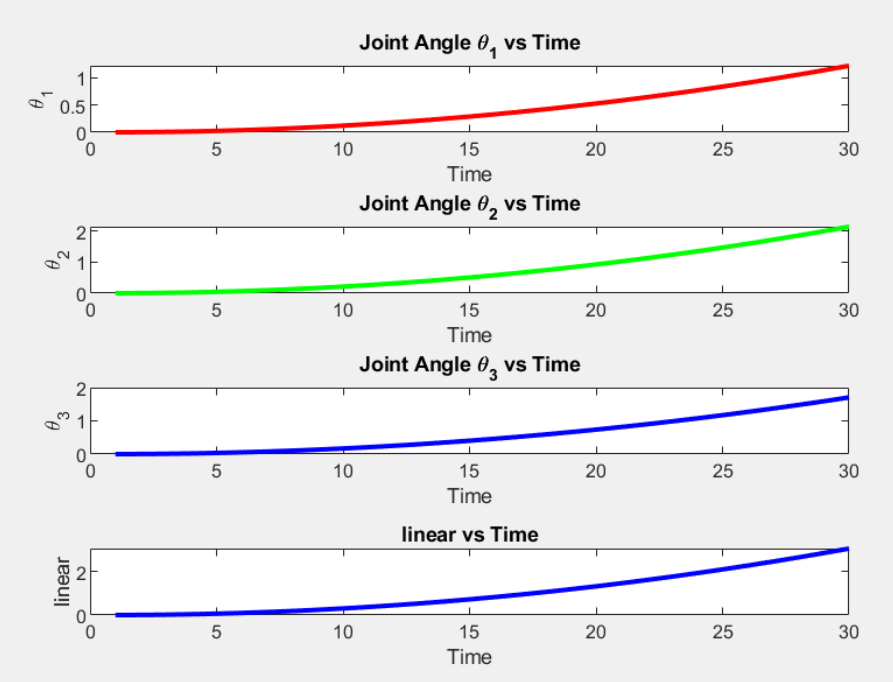

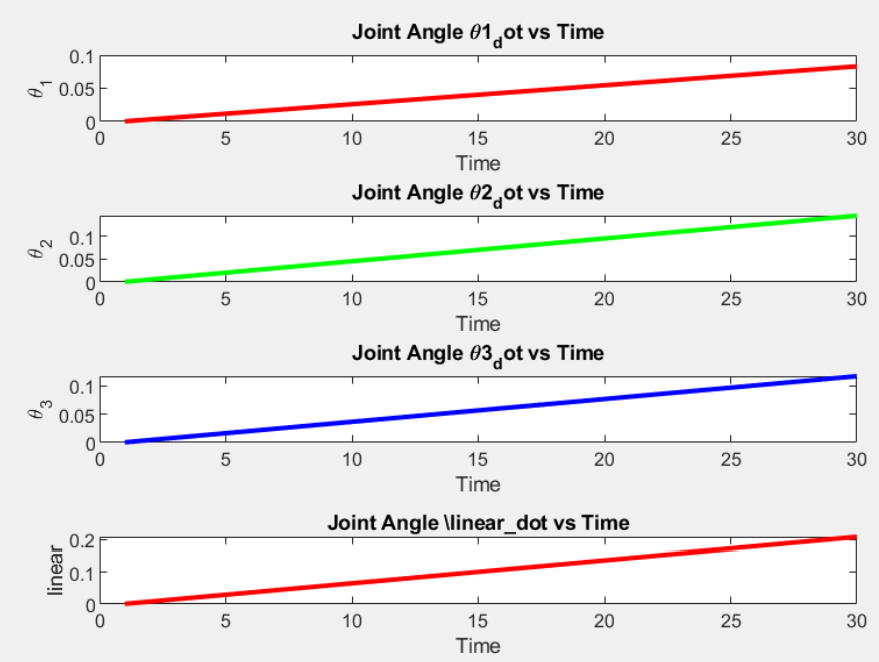

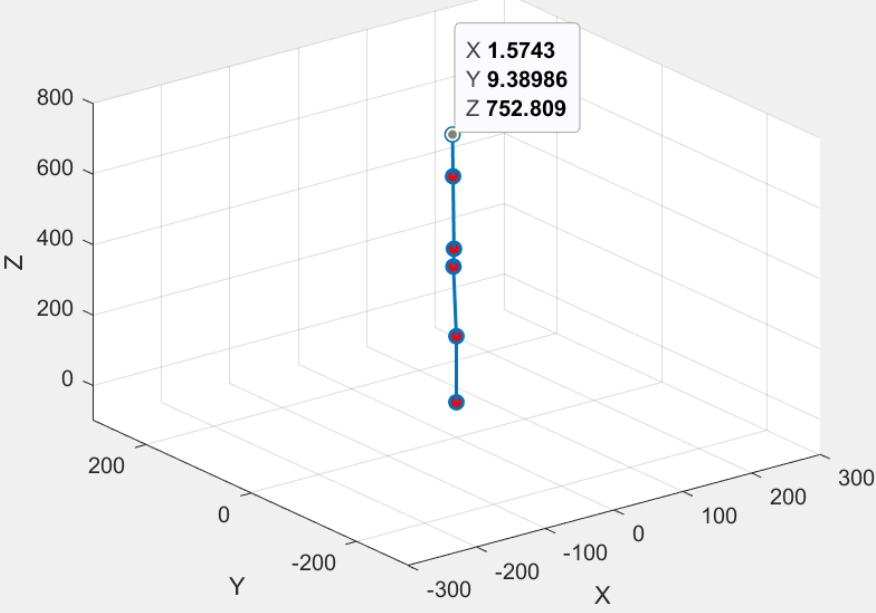

The preserved position and velocity curves rise under constant numerical inputs, which is qualitatively consistent with an undamped, continuously accelerated numerical model. They are evidence of a historical script run, not a validated physical response: the original parameter units and rigid-body derivation cannot be verified, and no raw arrays or execution log accompanied the figures.

### 6.3 Preserved PID results

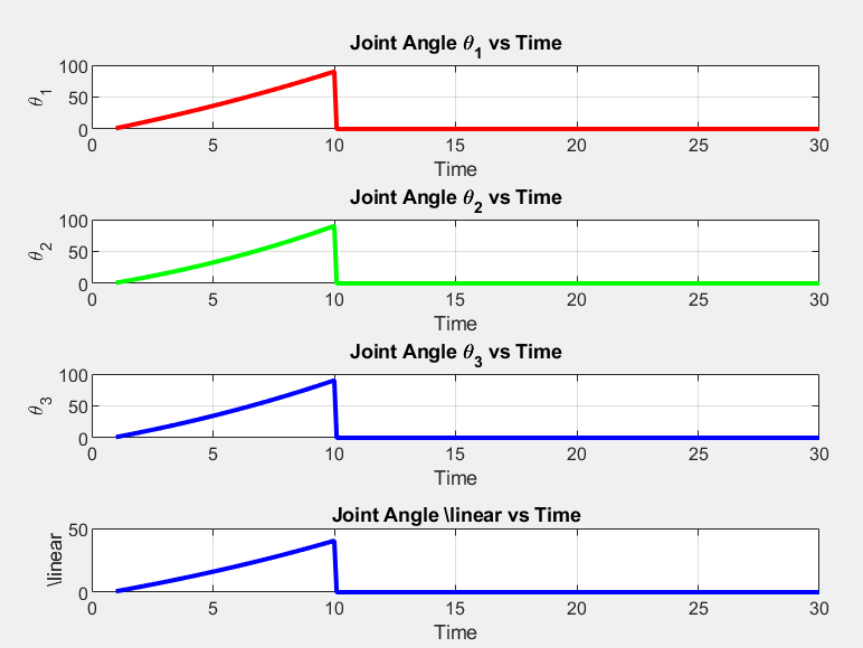

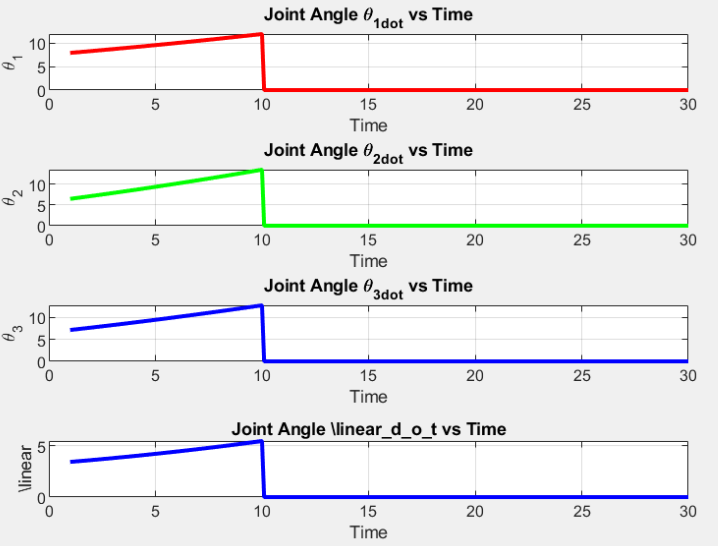

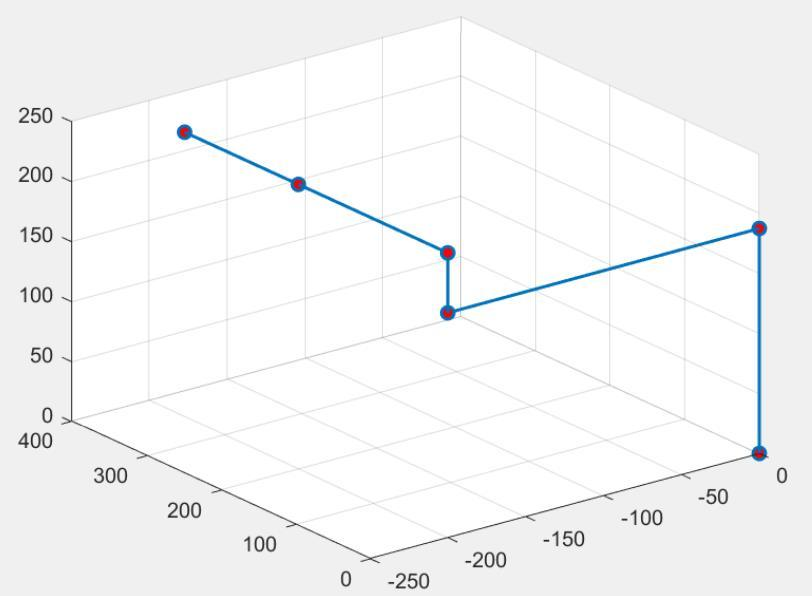

The rising portions are consistent with motion toward the requested coordinates. The later drop to zero is not a physical return to the origin; it is explained by early termination and untouched trailing entries in the preallocated arrays of the old source. The supplied historical terminal claim was $[90.0025^\circ,\,89.998^\circ,\,90.0495^\circ,\,40.3407\,\mathrm{mm}]^T$, but it cannot be independently recomputed from preserved raw data.

### 6.4 Provenance and interpretation

These six figures are deliberately retained as **historical results**, not outputs regenerated from the repaired MATLAB scripts. The repaired scripts correct state refresh, PID bookkeeping, the prismatic acceleration index, and the early-stop artifact, so a future verified run should not be expected to reproduce the old curves exactly. MATLAB or Octave was unavailable in the repair environment, and no new MATLAB numerical performance claim is made.

Physical units, a validated rigid-body derivation, the fourth diagonal choice `I5` versus `m5`, and equivalence to the Python frames remain unresolved. See [`src/matlab/README.md`](../src/matlab/README.md).

## 7. Reproduction

```bash
python -m pip install -r requirements.txt
python -B -m unittest discover -s tests -v
python -B src/python/benchmark_planners.py --output results/corrected/benchmark --duration 5 --candidates 12 --training-trajectories 48
```

The default benchmark uses seeds 0 through 19. The result JSON stores configuration, checker tolerances, raw trajectories, every planning-step wall time, separate fitting time, success subconditions, realized-cost breakdowns, and dependency metadata. Wall-clock measurements naturally vary with host load. Historical source before repair is preserved by Git tag `legacy-pre-technical-repair`.

## 8. Defensible public description

> A 4-DOF robotics portfolio project centered on scenario-specific GMM-guided trajectory sampling with MPC-style sampled receding-horizon selection, complete-link clearance checking, adaptive discretized swept-path evaluation, seeded candidate-count-matched baselines, and reproducible metrics; complemented by a separately scoped legacy MATLAB dynamics/PID study.

Do not describe the repository as a neural generative planner, a nonlinear optimal-control solver, a physically validated dynamic robot, an integrated MATLAB-Python plant, or a guaranteed robust/real-time collision-avoidance system.